In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [8]:
df = pd.read_csv('titanic_toy.csv')

In [9]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [10]:
df.isnull().sum()

,0
Age,177
Fare,45
Family,0
Survived,0


In [11]:
df.isnull().mean()

,0
Age,0.198653
Fare,0.050505
Family,0.000000
Survived,0.000000


In [12]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=2)

In [15]:
X_train['Age_99'] = X_train['Age'].fillna(99)
X_train['Age_minus1'] = X_train['Age'].fillna(-1)

X_train['Fare_999'] = X_train['Fare'].fillna(9999)
X_train['Fare_999'] = X_train['Fare'].fillna(-1)

In [16]:
print('Original Age variable variance:', X_train['Age'].var())
print('Age variance after 99 imputation:', X_train['Age_99'].var())
print('Age variance after -1 imputation:', X_train['Age_minus1'].var())

print('Original Fare variable variance:', X_train['Fare'].var())
print('Fare variance after 99 imputation:', X_train['Fare_999'].var())
print('Fare variance after -1 imputation:', X_train['Fare_minus1'].var())

Original Age variable variance: 204.3495133904614
Age variance after 99 imputation: 951.7275570187172
Age variance after -1 imputation: 318.0896202624484
Original Fare variable variance: 2448.197913706318
Fare variance after 99 imputation: 2378.5676784883503


KeyError: 'Fare_minus1'

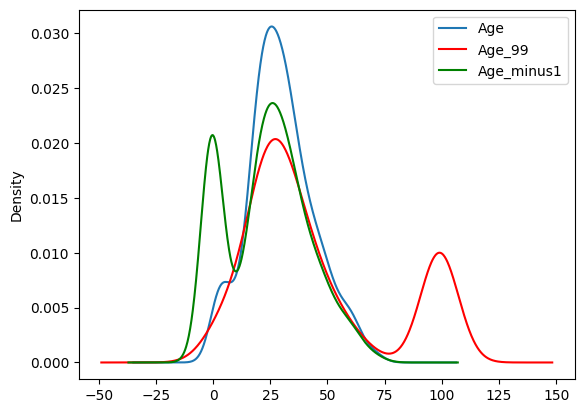

In [17]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original variable distribution
X_train['Age'].plot(kind='kde', ax=ax)

#variable imputed with the median
X_train['Age_99'].plot(kind='kde', ax=ax, color='red')

#variable imputed with the mean
X_train['Age_minus1'].plot(kind='kde', ax=ax, color='green')

#add legends
line, lables = ax.get_legend_handles_labels()
ax.legend(line, lables, loc='best')

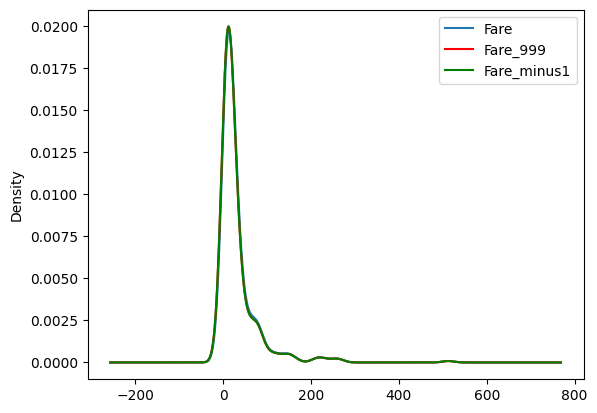

In [22]:
fig = plt.figure()
ax = fig.add_subplot(111)

#original variable distribution
X_train['Fare'].plot(kind='kde', ax=ax)

#variable imputed with the median
X_train['Fare_999'].plot(kind='kde', ax=ax, color='red')

#variable imputed with the mean
X_train['Fare_minus1'].plot(kind='kde', ax=ax, color='green')

#add legends
line, lables = ax.get_legend_handles_labels()
ax.legend(line, lables, loc='best')

In [23]:
X_train.cov()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,63.321188,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,16.553989,16.553989
Age_99,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-94.317400,-94.317400
Age_minus1,204.349513,125.558364,-4.149246,-189.535540,318.089620,114.394141,114.394141
Fare_999,63.321188,2448.197914,16.553989,-94.317400,114.394141,2378.567678,2378.567678
Fare_minus1,63.321188,2448.197914,16.553989,-94.317400,114.394141,2378.567678,2378.567678


In [24]:
X_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.084585,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.205233,0.205233
Age_99,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.062687,-0.062687
Age_minus1,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.131514,0.131514
Fare_999,0.084585,1.000000,0.205233,-0.062687,0.131514,1.000000,1.000000
Fare_minus1,0.084585,1.000000,0.205233,-0.062687,0.131514,1.000000,1.000000


# **Using Sklearn**

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=2)

In [26]:
from sklearn.impute import SimpleImputer
imputer1 = SimpleImputer(strategy='constant', fill_value=99)
imputer2 = SimpleImputer(strategy='constant', fill_value=999)

In [28]:
from sklearn.compose import ColumnTransformer
trf = ColumnTransformer([
    ('imputer1', imputer1, ['Age']),
    ('imputer2', imputer2, ['Fare'])
], remainder='passthrough')

In [29]:
trf.fit_transform(X_train)

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]])

In [30]:
trf.named_transformers_['imputer1'].statistics_

array([99.])

In [31]:
trf.named_transformers_['imputer2'].statistics_

array([999.])

In [32]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [33]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]])